In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/raw/store-data.csv', encoding="latin-1")

In [3]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10064.000000,9.863000e+03,9865.000000,10064.000000,10064.000000
mean,4994.397059,1.950322e+03,3.780233,0.157501,28.571309
std,2885.848580,4.410673e+04,2.240134,0.210586,233.509461
min,1.000000,4.440000e-01,-5.000000,0.000000,-6599.978000
25%,2496.750000,1.729000e+01,2.000000,0.000000,1.724800
50%,4989.500000,5.450000e+01,3.000000,0.200000,8.643600
75%,7494.250000,2.107600e+02,5.000000,0.200000,29.331600
max,9994.000000,1.131924e+06,14.000000,1.500000,8399.976000


In [4]:
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,10064,10064,9963,9763,10064,9713,10064,10064,10064,10064,9864,10064,10064,10064,10064,10064
unique,5009,1495,1334,4,793,810,6,1,633,86,705,4,1862,6,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035.0,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,39,35,5822,38,36,5163,10064,896,1967,259,3224,19,5942,1532,48


In [5]:
df.shape

(10064, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10064 entries, 0 to 10063
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10064 non-null  int64  
 1   Order ID       10064 non-null  object 
 2   Order Date     10064 non-null  object 
 3   Ship Date      9963 non-null   object 
 4   Ship Mode      9763 non-null   object 
 5   Customer ID    10064 non-null  object 
 6   Customer Name  9713 non-null   object 
 7   Segment        10064 non-null  object 
 8   Country        10064 non-null  object 
 9   City           10064 non-null  object 
 10  State          10064 non-null  object 
 11  Postal Code    9864 non-null   object 
 12  Region         10064 non-null  object 
 13  Product ID     10064 non-null  object 
 14  Category       10064 non-null  object 
 15  Sub-Category   10064 non-null  object 
 16  Product Name   10064 non-null  object 
 17  Sales          9863 non-null   float64
 18  Quanti

In [7]:
df.isna().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date        101
Ship Mode        301
Customer ID        0
Customer Name    351
Segment            0
Country            0
City               0
State              0
Postal Code      200
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales            201
Quantity         199
Discount           0
Profit             0
dtype: int64

In [8]:
df['Ship Mode'].isna().sum() # 301 order don't have shiping mode
df['Ship Mode'].mode() # Standard class is the most shiping mode assigned
df['Ship Mode'].value_counts()
df[df['Ship Mode'].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
28,29,US-2015-150630,9/17/2015,9/21/2015,NaN,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140.0,East,OFF-BI-10000474,Office Supplies,Binders,Avery Recycled Flexi-View Covers for Binding S...,9.618,2.0,0.7,-7.0532
94,95,CA-2015-149587,1/31/2015,2/5/2015,NaN,KB-16315,Karl Braun,Consumer,United States,Minneapolis,...,55407.0,Central,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,32.960,2.0,0.0,16.1504
191,192,CA-2015-102281,10/12/2015,10/14/2015,NaN,MP-17470,Mark Packer,Home Office,United States,New York City,...,10035.0,East,OFF-PA-10000061,Office Supplies,Paper,Xerox 205,51.840,8.0,0.0,24.8832
252,253,CA-2016-146941,12/10/2016,12/13/2016,NaN,DL-13315,Delfina Latchford,Consumer,United States,New York City,...,10024.0,East,OFF-ST-10001228,Office Supplies,Storage,"Fellowes Personal Hanging Folder Files, Navy",80.580,6.0,0.0,22.5624
314,315,CA-2014-167850,8/9/2014,8/16/2014,NaN,AG-10525,Andy Gerbode,Corporate,United States,Saint Petersburg,...,33710.0,South,TEC-PH-10002398,Technology,Phones,AT&T 1070 Corded Phone,178.384,2.0,0.2,22.2980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9911,9912,US-2014-157231,4/5/2014,4/9/2014,NaN,RP-19855,Roy Phan,Corporate,United States,Richmond,...,40475.0,South,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,115.360,7.0,0.0,56.5264
9964,9965,CA-2016-146374,12/5/2016,12/10/2016,NaN,HE-14800,Harold Engle,Corporate,United States,Newark,...,NaN,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.400,1.0,0.0,6.4320
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,NaN,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2.0,0.0,72.9480
10016,4904,CA-2017-110884,3/7/2017,3/12/2017,NaN,SH-20395,NaN,Consumer,United States,New York City,...,10035.0,East,OFF-LA-10003510,office supplies,Labels,Avery 4027 File Folder Labels for Dot Matrix P...,91.590,3.0,0.0,42.1314


In [9]:
df['City'] = df['City'].str.title()
df.drop_duplicates(['City'], keep=False)['Postal Code'].isna().sum()

np.int64(0)

In [10]:

dates_cols = ['Order Date', "Ship Date"]
df[dates_cols] = df[dates_cols].apply(pd.to_datetime, format="mixed")

df[dates_cols] = df[dates_cols].apply(lambda col: col.dt.strftime("%d/%m/%Y"))

(df['Ship Date'] < df["Order Date"]).sum()

np.int64(1159)

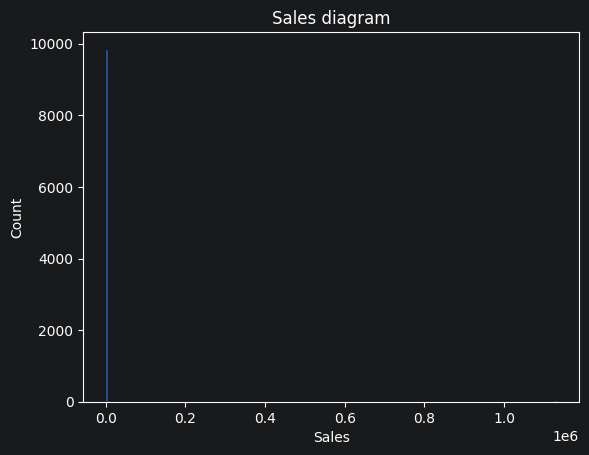

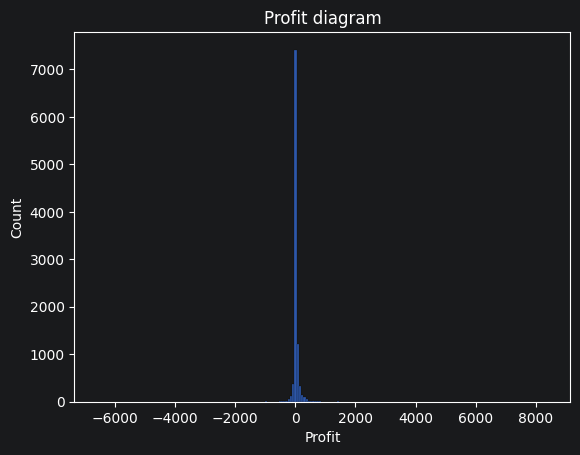

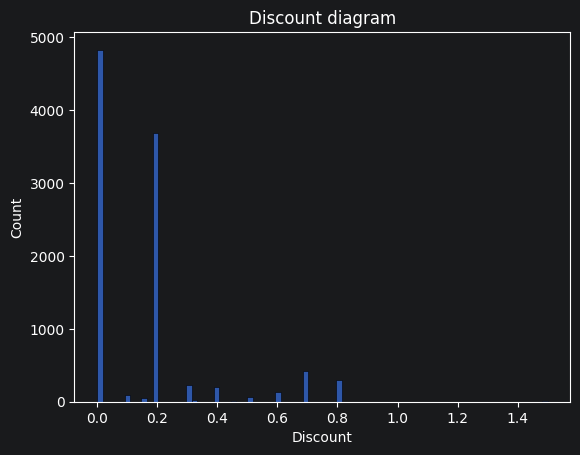

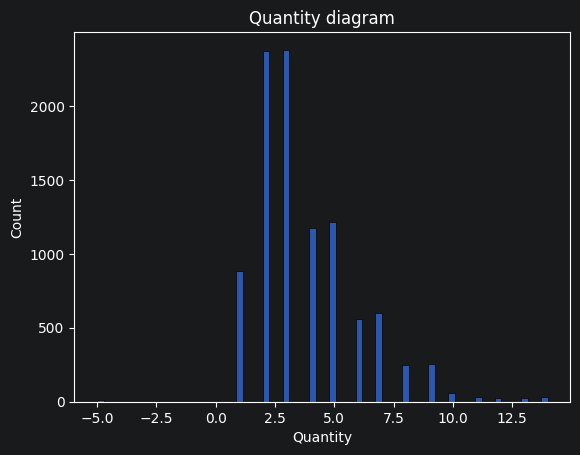

In [11]:
cols = ['Sales', 'Profit', 'Discount', 'Quantity']
for col in cols:
    sns.histplot(df[col])
    plt.title(f"{col} diagram")
    plt.show()

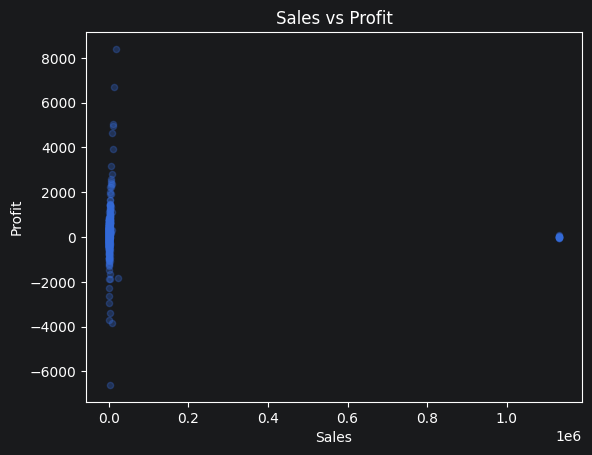

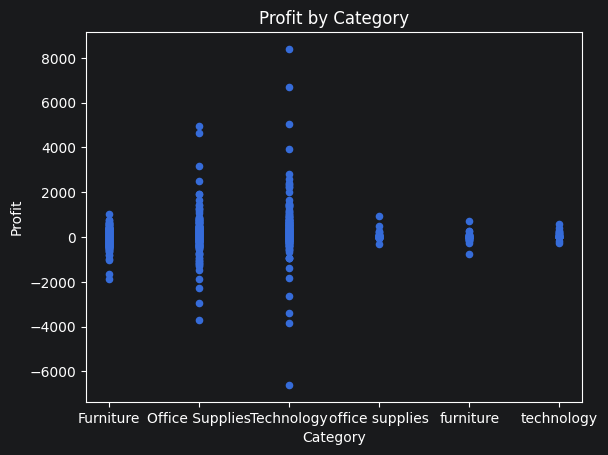

,Sales,Quantity,Discount,Profit
Sales,1.000000,-0.001902,0.004972,0.003309
Quantity,-0.001902,1.000000,0.014373,0.064227
Discount,0.004972,0.014373,1.000000,-0.215425
Profit,0.003309,0.064227,-0.215425,1.000000


In [12]:
df.plot.scatter(x='Sales', y='Profit', alpha=0.3)
plt.title('Sales vs Profit')
plt.show()

df.plot.scatter(y='Profit', x='Category')
plt.title('Profit by Category')
plt.show()

df[['Sales', 'Quantity', 'Discount', 'Profit']].corr() # correlation walo

(0.0, 200.0)

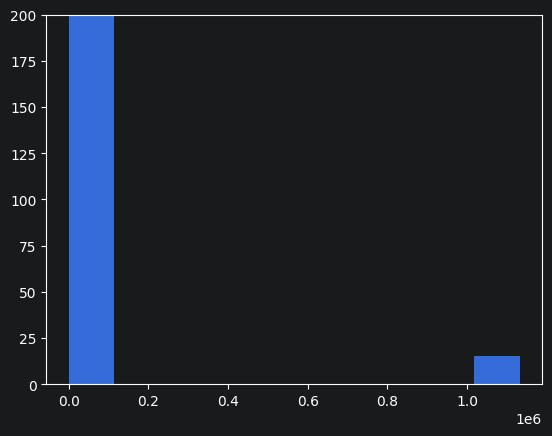

In [13]:
plt.hist(df['Sales'])
# plt.xlim(0, 10000)
plt.ylim(0, 200)

In [14]:
for col in ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']:
    print(df[col].value_counts())
    print()

Category
Office Supplies    5942
Furniture          2095
Technology         1826
office supplies     123
furniture            42
technology           36
Name: count, dtype: int64

Sub-Category
Binders        1532
Paper          1378
Furnishings     966
Phones          899
Storage         853
Art             803
Accessories     780
Chairs          622
Appliances      469
Labels          366
Tables          321
Envelopes       254
Bookcases       228
Fasteners       220
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

Segment
Consumer       5163
Corporate      3016
Home Office    1784
Consumerr        58
Corporrate       26
Home Ofice       17
Name: count, dtype: int64

Region
West       3224
East       2863
Central    2343
South      1634
Name: count, dtype: int64

Ship Mode
Standard Class    5822
Second Class      1896
First Class       1514
Same Day           531
Name: count, dtype: int64



In [15]:
df.groupby('Category')['Sub-Category'].unique()
df.isna().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date        101
Ship Mode        301
Customer ID        0
Customer Name    351
Segment            0
Country            0
City               0
State              0
Postal Code      200
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales            201
Quantity         199
Discount           0
Profit             0
dtype: int64

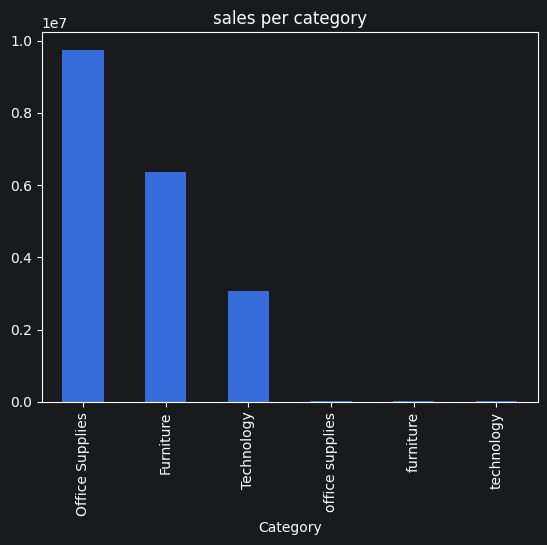

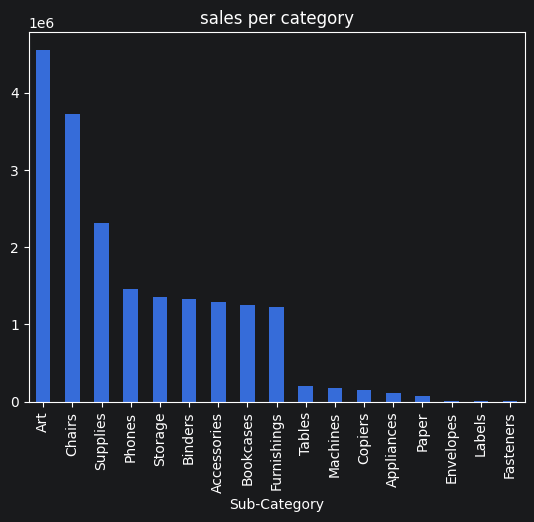

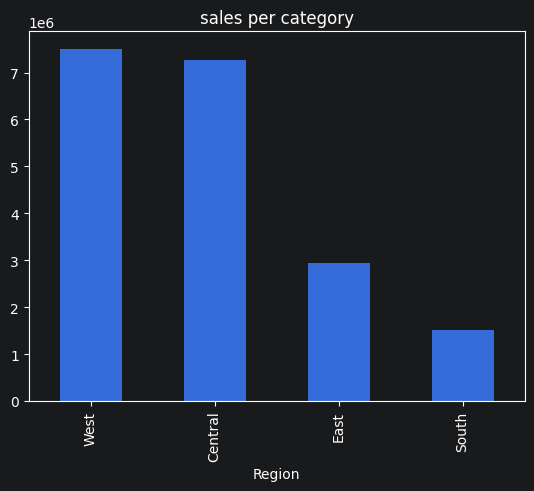

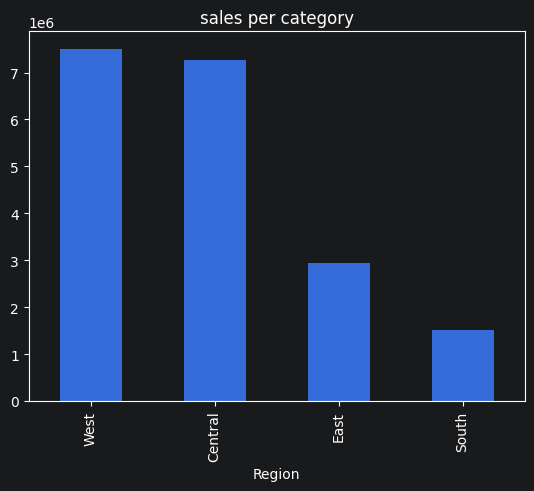

<Axes: xlabel='Segment'>

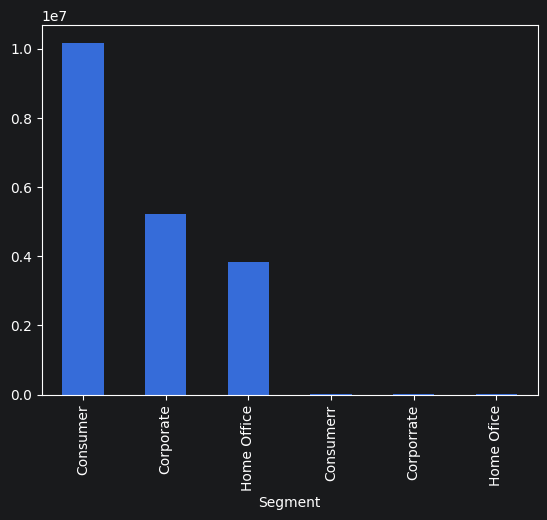

In [16]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('sales per category')
plt.show()

df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('sales per category')
plt.show()

df.groupby('Region')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('sales per category')
plt.show()

df.groupby('Region')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('sales per category')
plt.show()

df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='Category', ylabel='Profit'>

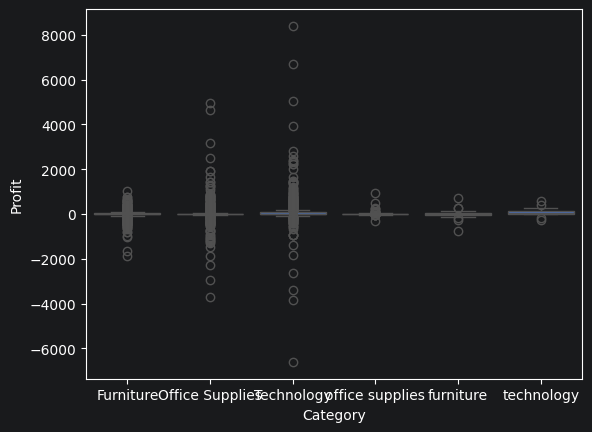

In [17]:
sns.boxplot(df, x='Category', y="Profit") # category names are duplicated

In [18]:
df[df['Profit'] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
14,15,US-2015-118983,22/11/2015,26/11/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106.0,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5.0,0.80,-123.8580
15,16,US-2015-118983,22/11/2015,26/11/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106.0,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3.0,0.80,-3.8160
23,24,US-2017-156909,16/07/2017,18/07/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140.0,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2.0,0.30,-1.0196
27,28,US-2015-150630,17/09/2015,21/09/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140.0,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7.0,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10025,4823,CA-2016-134222,10/07/2016,11/07/2016,Same Day,NZ-18565,NaN,Home Office,United States,Yuma,...,85364.0,West,OFF-BI-10001658,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,44.8560,6.0,0.70,-35.8848
10031,6743,US-2017-101784,06/07/2017,11/07/2017,Standard Class,PO-18850,NaN,Consumer,United States,Los Angeles,...,90008.0,West,FUR-CH-10001146,Furniture,Chairs,"Global Task Chair, Black",122.1360,3.0,0.20,-13.7403
10032,1878,CA-2017-118885,29/12/2017,02/01/2018,Standard Class,JG-15160,NaN,Consumer,United States,Los Angeles,...,90049.0,West,FUR-CH-10002880,Furniture,Chairs,"Global High-Back Leather Tilter, Burgundy",393.5680,4.0,0.20,-44.2764
10044,871,CA-2016-158099,03/09/2016,05/09/2016,First Class,PK-18910,PAUL KNUTSON,Home Office,United States,Philadelphia,...,19143.0,East,TEC-PH-10002496,Technology,Phones,Cisco SPA301,280.7820,3.0,0.40,-46.7970


In [19]:
df['Row ID'].duplicated().sum()
df.groupby('Customer ID')['Customer Name'].sum()

Customer ID
AA-10315    Alex AvilaAlex AvilaAlex AvilaAlex AvilaAlex A...
AA-10375    Allen ArmoldAllen ArmoldAllen ArmoldAllen Armo...
AA-10480    Andrew AllenAndrew AllenAndrew AllenAndrew All...
AA-10645    Anna AndreadiAnna AndreadiAnna AndreadiAnna An...
AB-10015    Aaron BergmanAaron BergmanAaron BergmanAaron B...
                                  ...                        
XP-21865    Xylona PreisXylona PreisXylona PreisXylona Pre...
YC-21895    Yoseph CarrollYoseph CarrollYoseph CarrollYose...
YS-21880    Yana SorensenYana SorensenYana SorensenYana So...
ZC-21910    Zuschuss CarrollZuschuss CarrollZuschuss Carro...
ZD-21925    Zuschuss DonatelliZuschuss DonatelliZuschuss D...
Name: Customer Name, Length: 793, dtype: object